In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pypsa
import pandas as pd
from pathlib import Path

idx = pd.IndexSlice

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [2]:
path = str(Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2030_free_{}{}.nc')

data = list()
for wiggle in (wiggles := [500, 3500]):

    n = pypsa.Network(path.format(wiggle, ''))
    hn = pypsa.Network(path.format(wiggle, '_50'))

    normal_opex = n.statistics.opex().sum() * 1e-9
    normal_capex = n.statistics.capex().sum() * 1e-9
    hike_opex = hn.statistics.opex().sum() * 1e-9
    hike_capex = hn.statistics.capex().sum() * 1e-9

    data.append({
        'wiggle': wiggle,
        'normal_opex': normal_opex,
        'normal_capex': normal_capex,
        'hike_opex': hike_opex,
        'hike_capex': hike_capex,
        'diff_opex': hike_opex - normal_opex,
        'diff_capex': hike_capex - normal_capex,
    })

df = pd.DataFrame(data)

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_500_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_3500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_free_3500_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [5]:
df

,wiggle,normal_opex,normal_capex,hike_opex,hike_capex,diff_opex,diff_capex
0,500,449.268430,491.064273,497.614804,500.057554,48.346374,8.993281
1,3500,505.199603,386.252845,696.180472,392.036502,190.980869,5.783657


In [40]:
capex_diff = (n.statistics.energy_balance() - hn.statistics.energy_balance())
print(capex_diff.sort_values().head(10))
print(capex_diff.sort_values().tail(10))

component  carrier                         bus_carrier         
Generator  oil primary                     oil primary            -3.992236e+08
Link       oil refining                    oil                    -3.790372e+08
           urban decentral oil boiler      urban decentral heat   -2.478195e+08
           lignite                         lignite                -1.165732e+08
           coal                            coal                   -1.037048e+08
           urban decentral biomass boiler  solid biomass          -1.001116e+08
           rural oil boiler                rural heat             -9.332648e+07
           electricity distribution grid   AC                     -8.208072e+07
           urban decentral oil boiler      co2                    -7.079377e+07
           rural biomass boiler            solid biomass          -6.339305e+07
dtype: float64
component  carrier                         bus_carrier         
Link       urban decentral biomass boiler  urban decentra

In [42]:
n.buses_t.marginal_price[gb].head()

Bus,AL0 0,AT0 0,BA0 0,BE0 0,BG0 0,CH0 0,CZ0 0,DE0 0,DE0 1,DE0 2,...,NL0 0,NO1 0,PL0 0,PT0 0,RO0 0,RS0 0,SE1 0,SI0 0,SK0 0,XK0 0
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,64.615710,68.593071,67.127595,25.897790,68.502371,69.784592,65.876067,33.738619,58.137161,10.159989,...,14.239121,47.804846,56.610140,72.527571,67.861929,67.041788,50.718570,67.758011,66.257750,66.247208
2024-01-01 03:00:00,64.615634,68.593054,67.127072,27.536264,68.633126,69.784751,65.876125,42.857747,59.349423,26.864869,...,24.563630,47.804843,61.398114,72.527575,67.861974,67.049051,50.718573,67.758751,66.260472,66.146233
2024-01-01 06:00:00,64.615343,67.507497,67.127919,39.443807,68.500029,69.784696,66.374080,48.637863,61.667328,39.236815,...,26.732099,47.804856,64.570388,72.527631,67.759944,67.101845,50.718586,67.488135,66.812816,66.276912
2024-01-01 09:00:00,58.871273,57.302434,61.806434,44.271425,60.577927,57.077023,61.376726,50.102032,55.734683,45.371999,...,37.671767,47.804862,62.628983,54.679648,62.629835,62.469297,50.718588,62.041847,62.073320,59.800546
2024-01-01 12:00:00,58.870557,56.936954,61.033866,46.139938,59.716065,57.750891,60.280351,50.100906,55.810679,45.046477,...,41.695793,47.804863,62.628987,54.387598,62.632884,61.877440,50.718591,60.564741,61.325345,59.802774


In [43]:
hn.buses_t.marginal_price[gb].head()

Bus,AL0 0,AT0 0,BA0 0,BE0 0,BG0 0,CH0 0,CZ0 0,DE0 0,DE0 1,DE0 2,...,NL0 0,NO1 0,PL0 0,PT0 0,RO0 0,RS0 0,SE1 0,SI0 0,SK0 0,XK0 0
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,60.441573,59.813447,62.516491,22.673348,63.207737,59.767951,58.171196,30.164878,48.576398,12.356624,...,13.793005,40.220326,48.682130,61.100278,62.869556,62.678531,42.240920,61.731896,60.462184,62.259205
2024-01-01 03:00:00,60.405653,59.813815,62.516517,22.674480,63.237029,59.745906,58.529757,30.410739,48.645276,14.228920,...,15.817239,40.220308,51.815766,61.100274,62.869423,62.617176,42.240785,61.732886,60.464465,62.176267
2024-01-01 06:00:00,60.403625,59.816164,62.516497,22.677903,63.206692,59.744031,58.922188,36.151367,50.607565,22.110118,...,14.686188,40.220322,56.495603,61.100380,62.831664,62.617428,42.240929,61.729273,60.473141,62.177959
2024-01-01 09:00:00,49.848073,48.260354,53.694201,25.675206,51.333830,48.341912,51.441520,36.261182,48.647806,25.038870,...,16.930550,40.220330,56.240183,45.810711,54.850332,54.001861,42.240946,52.066559,52.240315,51.496195
2024-01-01 12:00:00,49.845074,47.724197,53.702568,26.967350,51.319559,48.334728,52.474842,36.262396,48.644978,24.847479,...,19.248746,40.220337,56.240129,45.809009,54.904424,54.005059,42.240963,51.997881,52.443778,51.507403


(0.0, 200.0)

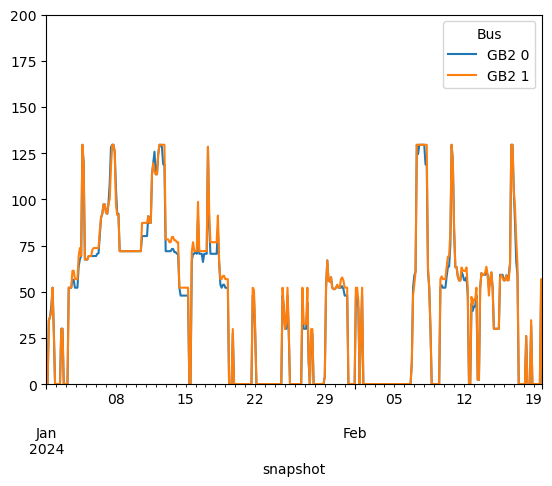

In [30]:
n.buses_t.marginal_price[['GB2 0', 'GB2 1']].head(400).plot()
plt.ylim(0, 200)

In [32]:
gb = n.buses.index[n.buses.carrier == 'AC']
mp = n.buses_t.marginal_price[gb].where(n.buses_t.marginal_price[gb] <= 1000)
vals = mp.std().astype(int).sort_values()

gaspower = eb.loc[idx[:, ['Combined-Cycle Gas', 'Open-Cycle Gas'], gb, 'AC']]
gaspower = gaspower.groupby(level=2).sum()

data = pd.DataFrame({'gaspower': gaspower, 'std': vals})
data


,gaspower,std
AL0 0,1.358513e+02,32
AT0 0,4.696580e+05,38
BA0 0,1.447126e+02,33
BE0 0,4.611319e+06,63
BG0 0,1.400190e+02,32
CH0 0,8.821797e+03,56
CZ0 0,3.488803e+05,52
DE0 0,8.067517e+05,44
DE0 1,5.921728e+05,47
DE0 2,4.198942e+06,49


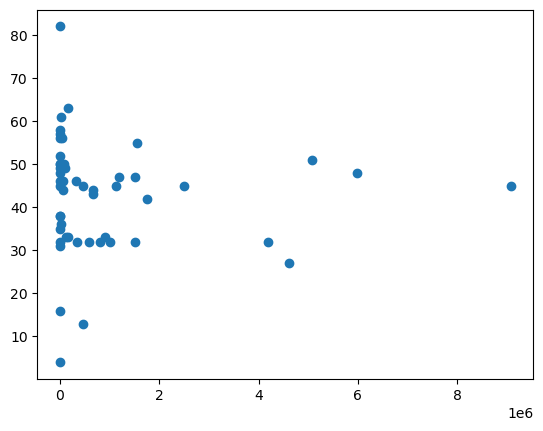

In [33]:
plt.scatter(gaspower, vals)